In [ ]:
import pandas as pd
import cnsplots as cns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from matplotlib.colors import to_rgb, to_hex
from collections import defaultdict
import joblib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

In [20]:
# define constants
COLNAME = "assigned_subcat" # hierarchy level to be analyzed, from here on defined as 'subcategory'
COLNAME_MAP = "Subcategory" # respective column name in the mapping file
TOP_COLNAME = "assigned_top" # hierarchy level to serve as top-level category/mapping
TOP_COLNAME_MAP = "Top_Category" # respective column name in the mapping file
SEQ_ID = 0.95 # sequence identity threshold used for clustering (part of input data file name)

# assertions
assert COLNAME and TOP_COLNAME in ["assigned_subcat", "assigned_cat", "assigned_top"], "Invalid column name. Must be one of 'assigned_subcat', 'assigned_cat', or 'assigned_top'."
assert COLNAME_MAP and TOP_COLNAME_MAP in ["Subcategory", "Category", "Top_Category"], "Invalid column name. Must be one of 'Subcategory', 'Category', or 'Top_Category'."
assert SEQ_ID in [0.95, 0.2], "Invalid sequence identity threshold. Must be one of 0.95, 0.2."

In [21]:
#######################
# plotting utilities 
#######################

# define colors for top-level categories
topcat_colors = {
    "Assembly": "#007BFF",
    "Structural": "#1e00ff",
    "Host takeover": "#2fff00",
    "NA processing": "#00ffb7",
    "Replication":"#00d9ff",
    "Translation": "#f6ff00",
    "AMGs": "#ffbf00", #"#ffa200",
    "Lysis": "#ff0000", 
    "Anti-Defense": "#ff00dd", 
    "Effectors": "#8e01f9", 
    "Lysogeny": "#FF5A00", #"#ff007b",
    "Unknown": "#bdbdbd", 
}

# define colors for mid-level categories
cat_colors = {
    "Transcriptional regulation": "#2fff00",
    "Transcriptional inhibition": "#02d136",
    "Host resource takeover": "#39fa69",
    "Transcriptional antitermination": "#60c006",
    "Host takeover via phosphorylation": "#3ea52e", 
    "Lytic switch": "#74d216",
    "Transcription factor": "#3C6D0F",
    "Transcriptional machinery": "#0D6806",

    "Integration": "#00ffb7",
    "Excision and transcriptional regulation": "#0dd09c",
    "DNA repair": "#0D916D",
    "Recombination": "#036D51",
    "RNA modification": "#71F8D4",
    "RNA cleavage": "#37F9AF",
    "RNA sealing": "#14AC72",

    "Maintenance": "#FF5A00", #"#ff007b",

    "Protein synthesis": "#f4fa51",
    "Ribosomal protein": "#f3fb00",
    "Translation regulation": "#d0d703",
    "Ribosome biogenesis": "#a0a512",
    "Protein maturation and folding": "#FFFF00",

    "Head morphogenesis": "#4099F9",
    "Head-to-tail joining": "#74B7FE",
    "Tail assembly": "#0F559F",
    "Baseplate assembly": "#014894",
    "DNA packaging": "#0E437B",

    "Replication initiation":"#00d9ff",
    "DNA replication":"#3AAEC3",

    "Capsid": "#1e00ff",
    "DNA injection": "#1903c1",
    "Tail and Fibers": "#553ffb",
    "Baseplate": "#3c2dad",

    "Host polysaccharide degradation": "#e24141", 
    "Endolysin": "#ff0000", 
    "Spanin": "#a90202", 
    "Lysis regulation": "#7D1C1C", 

    "Anti-Restriction": "#ff00dd", 
    "Anti-TA": "#e634f6", 
    "Anti-Defense": "#df00fd",

    "Nucleotide metabolism": "#ffbf00",
    "Other AMGs": "#ff9100",

    "Virulence factors": "#af01f9", 
    "Stress response and damage protection": "#7d01f9", 
    "Membrane transport and signaling": "#a312c3", 
    "Superinfection exclusion": "#710589", 

    "Unknown": "#bdbdbd", 
}


def adjust_color(color, factor=0.2, lighten=True):
    """Mix a color with white or black. The closer the value to 1, the more white/black contained"""
    r, g, b = to_rgb(color)

    if lighten:
        r = r + (1-r)*factor
        g = g + (1-g)*factor
        b = b + (1-b)*factor
    else:
        r = r * (1-factor)
        g = g * (1-factor)
        b = b * (1-factor)

    return to_hex((r, g, b))


def get_factor_range(n, min_n=2, max_n=20, min_spread=0.1, max_spread=0.5):
    """Returns factor range depending on n"""
    # normalize n to 0-1
    t = min(1, max(0, (n - min_n) / (max_n - min_n)))

    spread = min_spread + t * (max_spread - min_spread)

    base = 0.15 
    return base, base+spread


def generate_subcategory_colors(topcat_colors, cat_to_top):
    """Generate colors for subcategories based on their top-level category colors."""
    top_to_sub = defaultdict(list)
    for sub, top in cat_to_top.items():
        top_to_sub[top].append(sub)

    sub_colors = {}

    for top, subs in top_to_sub.items():
        base_color = topcat_colors.get(top, "#999999")
        n = len(subs)

        low, high = get_factor_range(n)

        if n == 1:
            factors = [0.2]
        else:
            factors = np.linspace(low, high, n)

        for i, (sub, factor) in enumerate(zip(subs, factors)):
            lighten = (i % 2 == 0) # alternate
            sub_colors[sub] = adjust_color(base_color, factor, lighten)

    return sub_colors

# lighten top-level category colors
topcat_colors_adjusted = {
    k: adjust_color(v, factor=0.2, lighten=True)
    for k, v in topcat_colors.items()
}

In [22]:
#######################
# Panel A: t-SNE plot (subcategory)
#######################

# read mapping file for keywords to sub-, mid-, and top-level categories
keywords_map = pd.read_csv("./input_data/Category_map.csv") 

# create a mapping from subcategories to top-level categories
cat_to_top = keywords_map[[COLNAME_MAP, TOP_COLNAME_MAP]].drop_duplicates().set_index(COLNAME_MAP)[TOP_COLNAME_MAP].to_dict()


def get_ordering_and_rank(colname_map, top_colname_map):
    if colname_map != "Top_Category":
        cat_to_top = keywords_map[[colname_map, top_colname_map]].drop_duplicates().set_index(colname_map)[top_colname_map].to_dict()
    else:
        cat_to_top = {x: x for x in keywords_map[colname_map].drop_duplicates()}
    unique_keys = pd.unique(list(cat_to_top.values()))
    rank = {cat: i for i, cat in enumerate(unique_keys)}
    return cat_to_top, rank


def get_color_maps(labels: List[str], metadata_col: str, topcol: str, cat_to_top) -> Dict[str, str]:
    """Generate a mapping from label values to colors

    Params
    -------
    labels (List[str]): List of category labels for each sample
    metadata_col (str): Column name used for coloring, determines color mapping strategy

    Returns
    -------
    Dict[str, str]: Dictionary mapping label values to colors
    """
    if metadata_col == "assigned_top":
        topcat_colors_adjusted = {
            k: adjust_color(v, factor=0.2, lighten=True)
            for k, v in topcat_colors.items()
        }
        color_map = {label: topcat_colors_adjusted.get(label) for label in labels}
        return color_map, topcat_colors_adjusted
    
    elif metadata_col in ("assigned_subcat", "assigned_cat"):
        if topcol == "assigned_top":
            colors = generate_subcategory_colors(topcat_colors, cat_to_top)
        elif topcol == "assigned_cat":
            colors = generate_subcategory_colors(cat_colors, cat_to_top)
        color_map = {label: colors.get(label) for label in labels}
        return color_map, colors


dict_map, rank = get_ordering_and_rank(COLNAME_MAP, TOP_COLNAME_MAP)
metadata = pd.read_csv(f"./input_data/metadata_BacVir.tsv", sep="\t")
metadata_df = metadata.copy()
labels = metadata_df[COLNAME].astype(str).values
color_map, source_palette = get_color_maps(labels, COLNAME, TOP_COLNAME, dict_map)

/tmp/ipykernel_3795288/2699439741.py:17: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_keys = pd.unique(list(cat_to_top.values()))


In [23]:
base_dir = Path("../../embeddings/outputs/prepare/BacVir")

model_dirs = [
    "ESM2_150",
    "ESM2_650",
    "ESM2_3B",
    "ESM3",
    "ESMC_300",
    "ESMC_600",
    "gLM2",
    "ProstT5",
    "ProtT5",
    #"PST-TL-T",
    #"PST-TL-P",
]

tsne_data = {}

for model in model_dirs:
    model_dir = base_dir / model

    data = joblib.load(model_dir / "tsne.joblib")
    metadata = pd.read_csv(model_dir / "metadata.tsv", sep="\t")

    tsne_data[model] = {
        "coords": data["coords"],
        "ids": data["ids"],
        "metadata": metadata.copy(),
    }

/tmp/ipykernel_3795288/2888729187.py:23: DtypeWarning: Columns (0,1,2,4,7,8,9,10,13,14,20,21,22,26,27,30,37,39,40,41,42,47,48,49,50,52,53,54,56,57,58,60,61,62,63,64,65,66,69,71,73,74,75,76,77,80,82,83,84,85,86,87,92,93,94,95,96,97) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(model_dir / "metadata.tsv", sep="\t")
/tmp/ipykernel_3795288/2888729187.py:23: DtypeWarning: Columns (0,1,2,4,7,8,9,10,13,14,20,21,22,26,27,30,37,39,40,41,42,47,48,49,50,52,53,54,56,57,58,60,61,62,63,64,65,66,69,71,73,74,75,76,77,80,82,83,84,85,86,87,92,93,94,95,96,97) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(model_dir / "metadata.tsv", sep="\t")
/tmp/ipykernel_3795288/2888729187.py:23: DtypeWarning: Columns (0,1,2,4,7,8,9,10,13,14,20,21,22,26,27,30,37,39,40,41,42,47,48,49,50,52,53,54,56,57,58,60,61,62,63,64,65,66,69,71,73,74,75,76,77,80,82,83,84,85,86,87,92,93,94,95,96,97) have mixed types. Specify dtyp

In [24]:
minimum = 1000000
maximum = 0
for model, values in tsne_data.items():
    if model not in ("ESM2_3B", "ESM3", "ESMC_600", "ProtT5", "ProstT5", "gLM2"):
        continue
    print(model)
    metadata = values["metadata"]
    phage = metadata[metadata["dataset"] == "PhageOnly"]
    bacvir = metadata[metadata["dataset"] == "BacVir"]
    assert len(phage) + len(bacvir) == len(metadata)
    if len(metadata) < minimum:
        minimum = len(metadata)
    if len(metadata) > maximum:
        maximum = len(metadata)
    print(f"Total: {len(metadata)}  PhageOnly: {len(phage)}   BacVir: {len(bacvir)}")
    print(f"Total failed: {94227-len(metadata)}  PhageOnly failed: {80774-len(phage)}   BacVir failed: {13453-len(bacvir)}")

print(f"Minimum = {minimum}")
print(f"Maximum = {maximum}")
print(f"+- = {(maximum-minimum)/2}")
print(f"Center = {minimum + (maximum-minimum)/2}")

ESM2_3B
Total: 94192  PhageOnly: 80774   BacVir: 13418
Total failed: 35  PhageOnly failed: 0   BacVir failed: 35
ESM3
Total: 93977  PhageOnly: 80729   BacVir: 13248
Total failed: 250  PhageOnly failed: 45   BacVir failed: 205
ESMC_600
Total: 94227  PhageOnly: 80774   BacVir: 13453
Total failed: 0  PhageOnly failed: 0   BacVir failed: 0
gLM2
Total: 94226  PhageOnly: 80774   BacVir: 13452
Total failed: 1  PhageOnly failed: 0   BacVir failed: 1
ProstT5
Total: 94195  PhageOnly: 80774   BacVir: 13421
Total failed: 32  PhageOnly failed: 0   BacVir failed: 32
ProtT5
Total: 94225  PhageOnly: 80774   BacVir: 13451
Total failed: 2  PhageOnly failed: 0   BacVir failed: 2
Minimum = 93977
Maximum = 94227
+- = 125.0
Center = 94102.0


In [6]:
def plot_tsne(ax, model):
    data = tsne_data[model]

    X_tsne = data["coords"]
    metadata_df = data["metadata"]

    labels = metadata_df["assigned_subcat"].values

    unique_values = pd.unique(labels)

    if "dataset" in metadata_df.columns:
        dataset_labels = metadata_df["dataset"].values

        for val in unique_values:
            color = color_map.get(val)

            if color is None:
                print(f"Skipping {val}: no color defined")
                continue

            label_mask = labels == val

            phage_mask = label_mask & (dataset_labels == "PhageOnly")
            bacvir_mask = label_mask & (dataset_labels == "BacVir")

            ax.scatter(X_tsne[phage_mask, 0], X_tsne[phage_mask, 1], color=color, label=val, lw=0.3, alpha=0.5, s=0.5, marker="o")
            ax.scatter(X_tsne[bacvir_mask, 0], X_tsne[bacvir_mask, 1], color=color, lw=0.3, alpha=0.5, s=0.5, marker="o")

    else:
        for val in unique_values:
            mask = labels == val

            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=val, color=color_map[val], lw=0.3, alpha=0.5, s=0.5)

    ax.set_xlabel("t-SNE1")
    ax.set_ylabel("t-SNE2")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

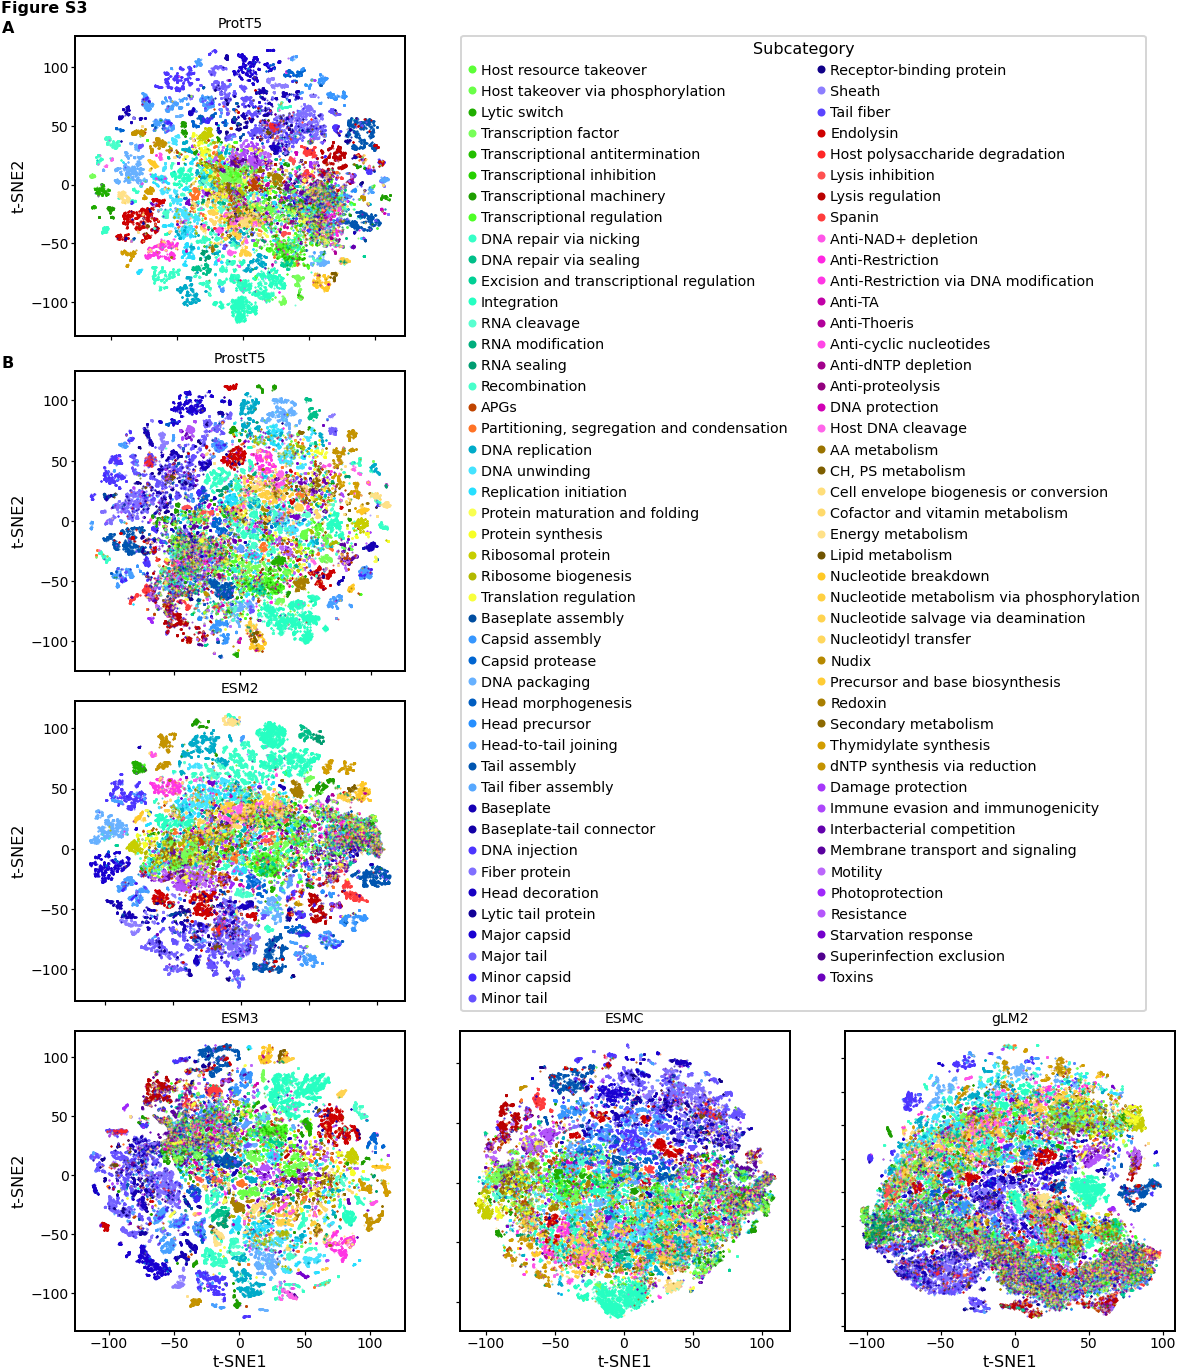

In [7]:
cns.settings.title_fontweight = "normal"
mp = cns.multipanel(
    max_width=600, title="Figure S3", title_fontweight="bold", loc="left"
)

######################
# Panel A: t-SNE plot colored for subcategory
mp.panel("A", 550, 500, margin_right=0)
ax = plt.gca()
ax.set_axis_off()

# t-SNE occupies the same size/position as the t-SNEs in Panel B
subax = ax.inset_axes((0.03, 0.7, 0.3, 0.3))
plot_tsne(subax, "ProtT5")

subax.set_xlabel("")
subax.set_xticklabels([])
subax.set_ylabel("t-SNE2")
subax.set_title("ProtT5", fontsize=7)

for spine in subax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

# Legend to the right of the t-SNE
n_col = 2
handles, labs = subax.get_legend_handles_labels()
ORDER = sorted(range(len(labs)), key=lambda i: (rank.get(dict_map.get(labs[i], ""), float("inf")), labs[i]))

legend_handles = [Line2D([0], [0], marker="o", linestyle="None", markerfacecolor=color_map[labs[i]], markeredgecolor=color_map[labs[i]], 
    markersize=6, alpha=1) for i in ORDER]

subax.legend(legend_handles, [labs[i] for i in ORDER], title="Subcategory", fontsize=7.1, loc="upper left", bbox_to_anchor=(1.17, 1),
    ncol=n_col, frameon=True, borderaxespad=0)

"""
# legend markerpoints with same alpha as used for plotting t-SNE
subax.legend([handles[i] for i in ORDER], [labs[i] for i in ORDER], title="Subcategory", fontsize=7.1,
    loc="upper left", bbox_to_anchor=(1.17, 1), ncol=n_col, frameon=True, scatterpoints=1,
    markerscale=6, borderaxespad=0)
"""
######################
# Panel B: t-SNE plot of various pLM embeddings
mp.panel("B", 550, 500, below="A", margin_top=-350)
ax = plt.gca()
ax.set_axis_off()

models_to_plot = [
    "ProstT5",
    "ESM2_3B",
    "ESM3",
    "ESMC_600",
    #"PST-TL-T",
    "gLM2",
    #"ProtT5",
]

display_names = {
    "ESM2_150": "ESM2",
    "ESM2_650": "ESM2",
    "ESM2_3B": "ESM2",
    "ESMC_300": "ESMC",
    "ESMC_600": "ESMC",
    "PST-TL-T": "PST",
    "PST-TL-P": "PST",
    "ESM3": "ESM3",
    "gLM2": "gLM2",
    "ProtT5": "ProtT5",
    "ProstT5": "ProstT5"
}

# positions: [left, bottom, width, height]
positions = [
    (0.03, 0.7, 0.3, 0.3),
    (0.03, 0.37, 0.3, 0.3),
    (0.03, 0.04, 0.3, 0.3),
    (0.38, 0.04, 0.3, 0.3),
    (0.73, 0.04, 0.3, 0.3),
]

for model, pos in zip(models_to_plot, positions):
    subax = ax.inset_axes(pos)
    plot_tsne(subax, model)
    subax.set_title(display_names[model], fontsize=7)

    # only show axis labels on bottom row
    if pos[1] > 0.1:
        subax.set_xlabel("")
        subax.set_xticklabels([])

    if pos[0] > 0.3:
        subax.set_ylabel("")
        subax.set_yticklabels([])

# Save final figure
outdir = Path("./plots/")
outdir.mkdir(parents=True, exist_ok=True)
cns.savefig(outdir / "FigureS3.svg")